<a href="https://www.kaggle.com/code/potalatarun/image-captioning-with-encoder-decoder?scriptVersionId=336190850" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nikhil7280/coco-image-caption/annotations_trainval2014/annotations/captions_train2014.json
/kaggle/input/datasets/nikhil7280/coco-image-caption/annotations_trainval2014/annotations/instances_train2014.json
/kaggle/input/datasets/nikhil7280/coco-image-caption/annotations_trainval2014/annotations/instances_val2014.json
/kaggle/input/datasets/nikhil7280/coco-image-caption/annotations_trainval2014/annotations/person_keypoints_val2014.json
/kaggle/input/datasets/nikhil7280/coco-image-caption/annotations_trainval2014/annotations/person_keypoints_train2014.json
/kaggle/input/datasets/nikhil7280/coco-image-caption/annotations_trainval2014/annotations/captions_val2014.json
/kaggle/input/datasets/nikhil7280/coco-image-caption/val2017/val2017/000000011197.jpg
/kaggle/input/datasets/nikhil7280/coco-image-caption/val2017/val2017/000000219485.jpg
/kaggle/input/datasets/nikhil7280/coco-image-caption/val2017/val2017/000000151000.jpg
/kaggle/input/datasets/nikhil7280/coco-image-c

KeyboardInterrupt: 

In [ ]:
df_train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv", index_col = 'id')
df_test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv", index_col = 'id')

In [ ]:
df_train.head()

In [ ]:
df_train.describe(include='all')

In [ ]:
df_train.info()

In [ ]:
(df_train.isnull().sum()/df_train.shape[0]) * 100

In [ ]:
df_train.isnull().sum()

In [ ]:
df_train.select_dtypes(include='number').corr()

In [ ]:
[df_train[i].unique() for i in df_train.select_dtypes(include='object').columns ]

In [ ]:
[[df_train[i].value_counts()] for i in df_train.select_dtypes(include='object').columns ]

In [ ]:
## from here i am using the coco dataset for image captioning

In [ ]:
import os
import json
import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
with open("/kaggle/input/datasets/nikhil7280/coco-image-caption/annotations_trainval2014/annotations/captions_train2014.json","r") as file:
    data = json.load(file)

In [ ]:
i = 1
for key, value in data.items():
    display(key)
    i+=1
    if i==10:
        break

In [ ]:
captions ={}
for i in data['annotations']:
    temp = captions.get(str(i['image_id']), [])
    temp.append(i['caption'])
    captions[str(i['image_id'])] = temp
# abc.sort()
# display(captions)
print(data['images'][0])

In [ ]:
data['annotations'][0]

In [89]:
import matplotlib.pyplot as plt
def pdplay(file_path, image_id):
    # img = plt.imread("/kaggle/input/datasets/nikhil7280/coco-image-caption/train2014/train2014/COCO_train2014_000000000009.jpg")
    img = plt.imread(file_path)

    plt.imshow(img)
    plt.show()
    if image_id:
        print(captions[str(image_id)])

In [ ]:
display(captions['9'])

In [ ]:
i = 0
for dirname, _, filenames in os.walk("/kaggle/input/datasets/nikhil7280/coco-image-caption/train2014/train2014"):
    for filename in filenames:
        filename = os.path.join(dirname, filename)
        name = filename.split(".")
        name = name[0].split("_")
        image_id = int(name[-1])
        pdplay(filename, image_id)
        print(int(name[-1]))
        i += 1
        if i == 9:
            break
    if i == 9:
        break

In [ ]:
# i need to combine the image to its captions in a single file so that i can use that while build dataset

In [ ]:
# create a dataframe kind of thing where i have cols of image_id, image_location and caption

In [ ]:
import pandas as pd

image_captions, image_ids, image_locations = [], [], []
data = []
for dirname, _, filenames in os.walk("/kaggle/input/datasets/nikhil7280/coco-image-caption/train2014/train2014", "r"):
    # print(dirname, _, filenames)
    for filename in filenames:
        name = filename.split(".")
        name = name[0].split("_")
        image_id = int(name[-1])

        image_captions.append(captions[str(image_id)])
        image_ids.append(image_id)
        image_locations.append(os.path.join(dirname, filename))
# df = pd.DataFrame([image_ids, image_locations, image_captions], ["image_id", "image_locations", "image_captions"])
# df.head()

In [ ]:
df = pd.DataFrame()
df["image_ids"] = image_ids
df["image_captions"] = image_captions
df["image_locations"] = image_locations

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.shape

In [46]:
import torch
from torch.utils.data import Dataset, DataLoader

In [47]:
from torchvision.io import decode_image
from torchvision.transforms import transforms
from torchvision.transforms import v2

In [48]:
class vocabulary():
    def __init__(self, captions):
        self.captions = captions
    def build_vocab(self):
        self.word_to_idx = {}
    
        self.word_to_idx["<start>"] = 1
        self.word_to_idx["<end>"] = 2
        self.word_to_idx["<unk>"] = 3
        self.idx = 4
        # print(self.captions)
        for caption in self.captions:
            tokens = caption[0].split(" ")
            for token in tokens:
                if token not in self.word_to_idx:
                    self.word_to_idx[str(token)] = self.idx
                    self.idx += 1
                    
        self.idx_to_word = {val:key for key,val in self.word_to_idx.items()}

    def __call__(self, word):
        if word in self.word_to_idx:
            return self.word_to_idx[word]
        else:
            return self.word_to_idx["<unk>"]
    def __len__(self):
        return len(self.word_to_idx)

In [49]:
#build the vocabulary
vocab = vocabulary(df['image_captions'])
vocab.build_vocab()

In [50]:
len(vocab)

19389

In [55]:
class image_captions_dataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.transform = v2.Compose([
            v2.Resize((224,224)),
            v2.ConvertImageDtype(torch.float32),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    def __len__(self):
        return self.df.shape[0]
    def __getitem__(self, idx):
        img_caption = self.df['image_captions'][idx][0]
        img_path = self.df['image_locations'][idx]

        img = decode_image(str(img_path), mode="RGB")
        img = self.transform(img)
        
        img_caption = "<start> " + img_caption # + " <end>" 
        caption_tokens = [vocab(str(word)) for word in img_caption.split(" ")]
        
        for i in range(len(caption_tokens), 13):
            caption_tokens.append(0)
        caption_tokens = caption_tokens[:13]
        caption_tokens.append(2)
        return (torch.tensor(caption_tokens), img)
    

In [56]:
train_dataset = image_captions_dataset(df)

In [57]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)

In [58]:
for i in iter(train_loader):
    print( i[0].shape)
    shit = i[1]
    print(i[1].shape, i[1][0])
    break

torch.Size([16, 14])
torch.Size([16, 3, 224, 224]) tensor([[[ 0.1254, -0.1486,  0.3138,  ..., -1.0733, -0.1143, -0.3369],
         [ 0.0227,  0.1254, -0.2684,  ..., -1.1075, -0.7993, -1.0390],
         [-0.0972, -0.1657, -0.3369,  ..., -1.3302, -1.5870, -1.9809],
         ...,
         [-0.4054, -0.2856, -0.3541,  ..., -0.1657, -0.1828, -0.1999],
         [-0.4568, -0.3712, -0.4054,  ..., -0.1828, -0.1999, -0.1999],
         [-0.4739, -0.4397, -0.4397,  ..., -0.2171, -0.1999, -0.2171]],

        [[ 0.2927,  0.0301,  0.4503,  ..., -0.8102,  0.2052, -0.1275],
         [ 0.1702,  0.3452, -0.1800,  ..., -0.9153, -0.5301, -0.8277],
         [-0.0049, -0.0399, -0.2675,  ..., -1.1954, -1.3880, -1.8081],
         ...,
         [-0.3375, -0.2325, -0.2325,  ..., -0.0049, -0.0049, -0.0399],
         [-0.3901, -0.3200, -0.2850,  ..., -0.0049, -0.0049, -0.0049],
         [-0.3901, -0.3725, -0.3725,  ..., -0.0224, -0.0399, -0.0224]],

        [[ 0.4265,  0.1302,  0.6705,  ..., -0.6715,  0.4091,  0.1

In [59]:
import torchvision
import torch.nn as nn
import torchvision.models as models
class Encoder_model(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet50(pretrained=True)

        for param in resnet.parameters():
            param.requires_grad_(False)
        
        modules = list(resnet.children())[:-1]

        self.resnet = nn.Sequential(*modules)
        self.embed = nn.Linear(resnet.fc.in_features, embed_size)

        self.bn = nn.BatchNorm1d(embed_size, momentum=0.01)

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.embed(features)
        features = self.bn(features)
        return features

In [60]:
cnn_model = Encoder_model(52)

In [61]:
cnn_model(shit).size()

torch.Size([16, 52])

In [62]:
length = 0
for i in df['image_captions']:
    length = max(length, len(i[0].split(" ")))
    # print(i[0])
    # break

In [63]:
class Decoder_model(nn.Module):
    def __init__(self, embed_size, num_layers, hidden_size, vocab_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed_size = embed_size
        self.num_layers = num_layers
        self.vocab_size = vocab_size

        self.embeddings = nn.Embedding(self.vocab_size, self.embed_size)

        self.lstm = nn.LSTM(self.embed_size, self.hidden_size, self.num_layers, batch_first = True)

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        self.batch_size = features.shape[0]
        self.seq_length = features.shape[1]

        self.hidden = (torch.randn(self.num_layers, self.batch_size, self.hidden_size),
                      torch.randn(self.num_layers, self.batch_size, self.hidden_size)
                      )
        captions = captions[:,:-1]
        embeddings = self.embeddings(captions)
        features = features.view(self.batch_size, 1, self.embed_size)
        embeddings = torch.cat((features, embeddings), dim=1)
        lstm_out, hidden = self.lstm(embeddings, self.hidden)
        lstm_out = self.dropout(lstm_out)

        lstm_out = lstm_out.contiguous()

        outputs = self.fc(lstm_out)

        return outputs

In [93]:
import math
def train():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    !(mkdir models)
    embed_size = 512
    hidden_size = 512
    num_layers = 1
    vocab_size = 19389
    encoder = Encoder_model(embed_size)
    decoder = Decoder_model(embed_size, num_layers, hidden_size, vocab_size)

    criterion = nn.CrossEntropyLoss().cuda if torch.cuda.is_available() else nn.CrossEntropyLoss()

    params = list(encoder.embed.parameters()) + list(encoder.bn.parameters()) + list(decoder.parameters())

    optimizer = torch.optim.Adam(params, lr=0.001, betas=(0.9, 0.999), eps=1e-08)

    total_step = math.ceil(len(train_loader.dataset)/len(train_loader.batch_sampler))
    for epoch in range(15):
        for i_step in range(1, total_step):
            captions, images = (next(iter(train_loader)))
    
            encoder.zero_grad()
            decoder.zero_grad()
            
            image_embeddings = encoder(images)
    
            outputs = decoder(image_embeddings, captions)
    
            loss = criterion(outputs.view(-1, vocab_size), captions.view(-1))
    
            loss.backward()
    
            optimizer.step()
            
            stats = 'Epoch [%d/%d], Step [%d/%d], Loss: %.4f, Perplexity: %5.4f' % (epoch, 14, i_step, total_step, loss.item(), np.exp(loss.item()))
            print(stats)
            if i_step%100 == 0:
                print(stats)
        
        torch.save(encoder.state_dict(), os.path.join('./models', 'encoder3-%d.pkl' % epoch))
        torch.save(decoder.state_dict(), os.path.join('./models', 'decoder3-%d.pkl' % epoch))
    # print(outputs)
    # print(device)

In [ ]:
train()

mkdir: cannot create directory ‘models’: File exists
Epoch [0/14], Step [1/16], Loss: 9.8748, Perplexity: 19433.8578
Epoch [0/14], Step [2/16], Loss: 9.6921, Perplexity: 16189.8012
Epoch [0/14], Step [3/16], Loss: 9.5960, Perplexity: 14705.1070
Epoch [0/14], Step [4/16], Loss: 9.4105, Perplexity: 12216.4965
Epoch [0/14], Step [5/16], Loss: 9.3178, Perplexity: 11134.4118
Epoch [0/14], Step [6/16], Loss: 9.0353, Perplexity: 8394.3055
Epoch [0/14], Step [7/16], Loss: 8.8783, Perplexity: 7174.2326
Epoch [0/14], Step [8/16], Loss: 8.5030, Perplexity: 4929.6447
Epoch [0/14], Step [9/16], Loss: 8.5258, Perplexity: 5043.2233
Epoch [0/14], Step [10/16], Loss: 8.1224, Perplexity: 3369.0014
Epoch [0/14], Step [11/16], Loss: 7.8210, Perplexity: 2492.4883
Epoch [0/14], Step [12/16], Loss: 7.0323, Perplexity: 1132.6105
Epoch [0/14], Step [13/16], Loss: 6.6897, Perplexity: 804.0830
Epoch [0/14], Step [14/16], Loss: 6.3674, Perplexity: 582.5380
Epoch [0/14], Step [15/16], Loss: 6.1615, Perplexity: 474

In [ ]:
# inferencing

In [105]:
embed_size, hidden_size, vocab_size, num_layers = 512, 512, 19389, 1

encoder = Encoder_model(embed_size)
encoder.eval()
decoder = Decoder_model(embed_size, num_layers, hidden_size, vocab_size)
decoder.eval()

Decoder_model(
  (embeddings): Embedding(19389, 512)
  (lstm): LSTM(512, 512, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=19389, bias=True)
)

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder.load_state_dict(torch.load("/kaggle/working/models/encoder3-14.pkl"))
decoder.load_state_dict(torch.load("/kaggle/working/models/decoder3-14.pkl"))

encoder.to(device)
decoder.to(device)

Decoder_model(
  (embeddings): Embedding(19389, 512)
  (lstm): LSTM(512, 512, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=19389, bias=True)
)

In [110]:
def sample(image_path, embed_size):
    image_tensor = decode_image(str(image_path), mode = "RGB")
    transform = v2.Compose([
            v2.Resize((224,224)),
            v2.ConvertImageDtype(torch.float32),
            # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    features = transform(image_tensor)

    features = encoder(features.view(1,3,224,224))

    features = features.view(1,1, embed_size)

    states = (
        torch.randn(1, 1, embed_size),
        torch.randn(1, 1, embed_size)
    )

    captions = []

    for word in range(10):
        lstm_out, states = decoder.lstm(features, states)
        lstm_out = lstm_out.contiguous()

        word_pred = decoder.fc(lstm_out)

        prediction = word_pred.argmax(dim=2)

        captions.append(prediction.item())

        features = decoder.embeddings(prediction.view(1, -1)).view(1, 1, -1)

    return captions
        

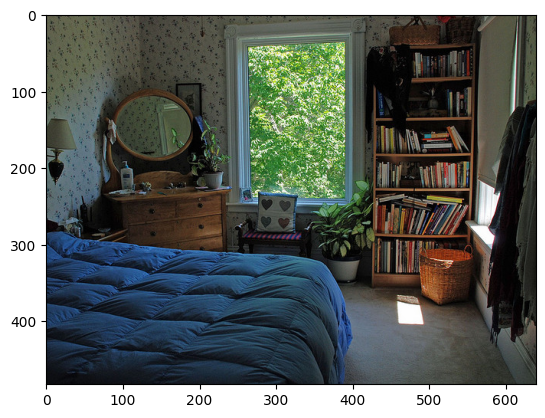

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


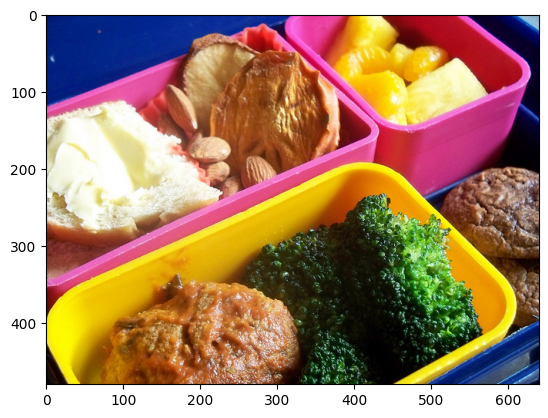

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


In [111]:
img_paths = ["/kaggle/input/datasets/nikhil7280/coco-image-caption/val2017/val2017/000000000632.jpg", 
             "/kaggle/input/datasets/nikhil7280/coco-image-caption/train2014/train2014/COCO_train2014_000000000009.jpg",
            ]
for img_path in img_paths[:10]:
    outputs = sample(img_path, 512)
    pdplay(img_path, None)
    print([vocab.idx_to_word[i] if i!=0 else 0 for i in outputs])

In [ ]:
image_paths = [os.path.join(dir_name, filename) for dir_name,_, filenames in os.walk("/kaggle/input/datasets/nikhil7280/coco-image-caption/train2014/train2014") for filename in filenames[:10]]

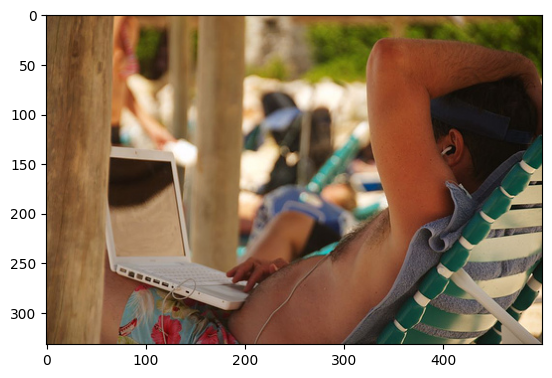

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


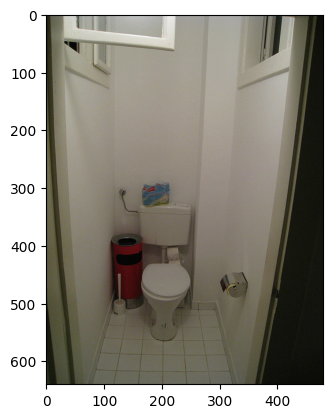

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


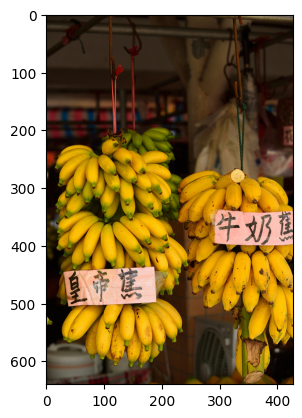

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


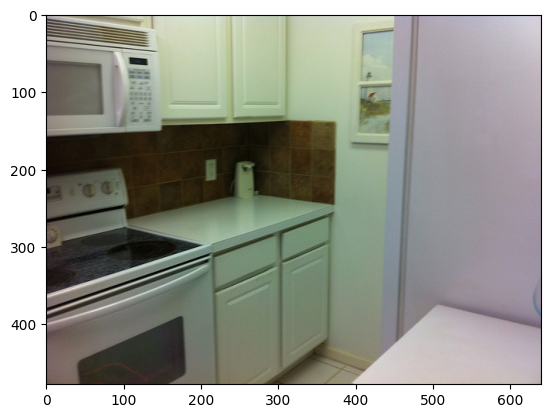

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


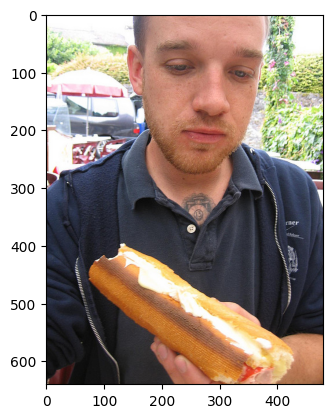

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


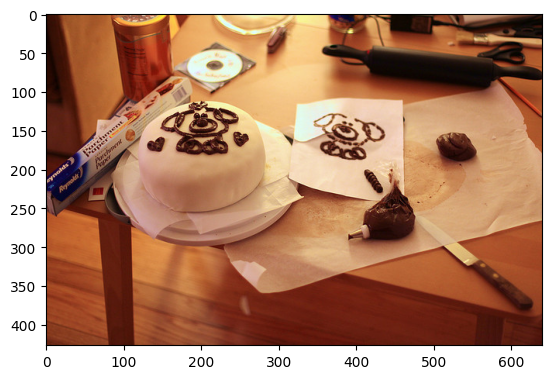

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


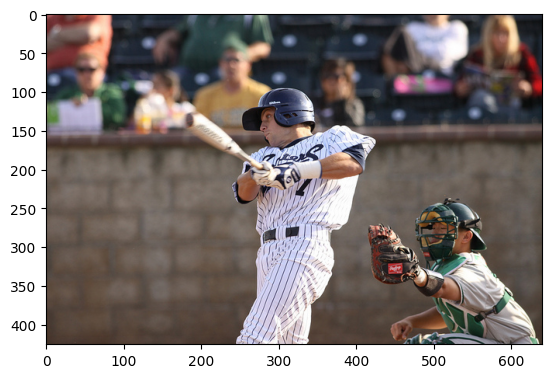

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


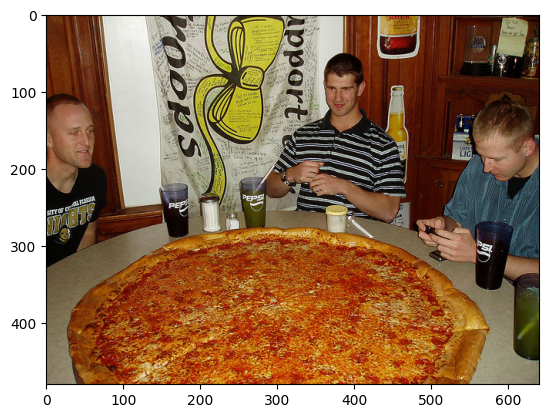

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


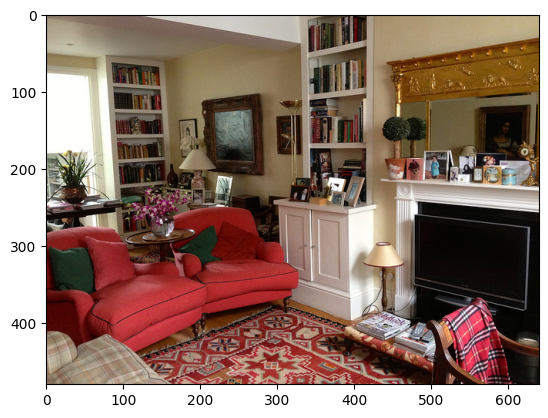

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


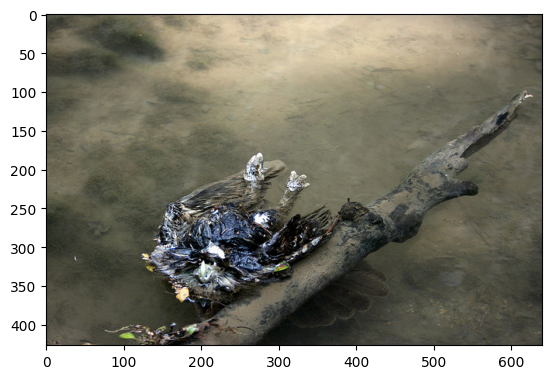

['<start>', 'A', 'man', 'is', 'sitting', 'on', 'a', 'table', 'with', 'a']


In [112]:
for img_path in image_paths[:10]:
    outputs = sample(img_path, 512)
    pdplay(img_path, None)
    print([vocab.idx_to_word[i] if i!=0 else 0 for i in outputs])

In [79]:
for i in df.image_captions:
    if "A man".lower() in i[0].lower():
        print(i[0])

A man laying on a lawn chair using a laptop computer.
A man who is eating a hot dog.
A man holding a yellow frisbee on top of a green field.
A man holding a black and white dog over a kitchen counter.
Two woman and a man sit atop a sculpture. 
A man riding skis on top of a snow covered slope.
A man and two cats laying on a bed.
A man in white jacket skiing next to trees.
A man dressed in an outfit like a little girl.
A man with a baseball glove holding a ball in a pitch
A man riding a wave on top of a surfboard.
A man and a woman shovel hot dogs down their mouth
A man in the air surfing in deep waters of the sea
A man stretches to hit the tennis ball.
A man holding a skateboard over the top of his head.
A man on a field swinging a baseball bat.
A man swinging a baseball bat at a baseball.
A man standing on a lush green field with a soccer ball.
A man riding an ocean wave on a surfboard.
A man riding a skateboard next to a green metal fence.
A man flying through the air on top of a skat

torch.Size([3, 224, 224])


TypeError: Invalid shape (3, 224, 224) for image data

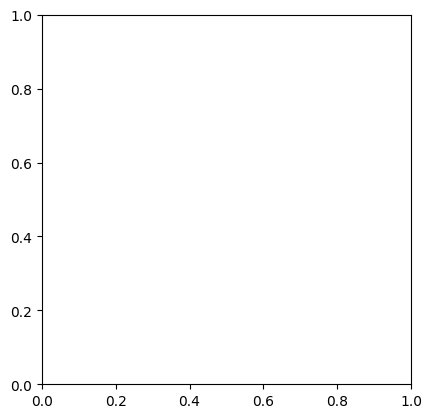